In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display
import ipywidgets as widgets
import pandas as pd
import sympy as sp
import scipy.stats as stats
import sympy as sp
import jax
import jax
import jax.numpy as jnp
from jax.scipy.special import ndtr
import os

%matplotlib ipympl




# Monte Carlo Simulation

- Simulating basic random variables (Bernoulli, exponential) and comparing sample means to known expectations
- Extending to financial applications by simulating stock price paths




In [2]:
tickers = ["AAPL", "JPM", "XOM", "KO"]
#data = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]


In [3]:
close_price = pd.read_csv("../data_general/4_ticker_data.csv")
close_price = close_price.set_index("Date")

In [4]:
close_price

,AAPL,JPM,KO,XOM
Date,,,,
2020-01-02,72.400528,118.430328,45.432716,53.306408
2020-01-03,71.696640,116.867462,45.184849,52.877857
2020-01-06,72.267929,116.774551,45.168324,53.283859
2020-01-07,71.928047,114.789276,44.821320,52.847786
2020-01-08,73.085121,115.684769,44.903934,52.050823
...,...,...,...,...
2024-12-24,256.797211,235.018585,60.622307,101.953667
2024-12-26,257.612732,235.823593,60.361835,102.039902
2024-12-27,254.201370,233.912888,60.246071,102.030319


In [5]:
returns = close_price.pct_change()
returns.dropna(inplace=True)
returns

,AAPL,JPM,KO,XOM
Date,,,,
2020-01-03,-0.009722,-0.013197,-0.005456,-0.008039
2020-01-06,0.007968,-0.000795,-0.000366,0.007678
2020-01-07,-0.004703,-0.017001,-0.007682,-0.008184
2020-01-08,0.016087,0.007801,0.001843,-0.015080
2020-01-09,0.021241,0.003651,0.018215,0.007655
...,...,...,...,...
2024-12-24,0.011478,0.016444,0.007374,0.000941
2024-12-26,0.003176,0.003425,-0.004297,0.000846
2024-12-27,-0.013242,-0.008102,-0.001918,-0.000094


In [6]:
log_returns = np.log1p(returns)
log_returns

,AAPL,JPM,KO,XOM
Date,,,,
2020-01-03,-0.009770,-0.013284,-0.005471,-0.008072
2020-01-06,0.007937,-0.000795,-0.000366,0.007649
2020-01-07,-0.004714,-0.017147,-0.007712,-0.008218
2020-01-08,0.015959,0.007771,0.001842,-0.015195
2020-01-09,0.021018,0.003645,0.018052,0.007626
...,...,...,...,...
2024-12-24,0.011413,0.016310,0.007347,0.000940
2024-12-26,0.003171,0.003419,-0.004306,0.000845
2024-12-27,-0.013331,-0.008135,-0.001920,-0.000094


# Analysis of AAPL

In [7]:
aapl_log_returns = log_returns["AAPL"]

In [8]:
aapl_log_returns.describe()

count    1257.000000
mean        0.000983
std         0.019940
min        -0.137708
25%        -0.008461
50%         0.001186
75%         0.011918
max         0.113158
Name: AAPL, dtype: float64

 ### fitting different distrubutions with stats.fit

Stats fit finds the best possible parameters for each distrubution with Maximum Likelihood Estimation

In [9]:
norm_params    = stats.norm.fit(aapl_log_returns)
norm_params

(np.float64(0.0009828783497584607), np.float64(0.019932238160837387))

μ ≈ 0.00098
σ ≈ 0.01993

Daily mean log return: μ ≈ 0.00098 (≈ 0.10%/day)

daily volatility is ~%2

In [10]:
t_params       = stats.t.fit(aapl_log_returns)
t_params

(np.float64(3.6021403829973235),
 np.float64(0.00124352549468655),
 np.float64(0.013671311791477177))

In [11]:
laplace_params = stats.laplace.fit(aapl_log_returns)
laplace_params

(np.float64(0.0011859889019078477), np.float64(0.014013350126690485))

### Goodnes of Fit


In [12]:
gof_norm = stats.goodness_of_fit(stats.norm,    aapl_log_returns, statistic='ad')

In [13]:
gof_norm

GoodnessOfFitResult(fit_result=  params: FitParams(loc=np.float64(0.0009828783497584607), scale=np.float64(0.019940171390270246))
 success: True
 message: 'The fit was performed successfully.', statistic=np.float64(12.255620366433504), pvalue=np.float64(0.0001), null_distribution=array([0.39275956, 0.15511179, 0.32441667, ..., 0.64526008, 0.44431804,
       0.46947233], shape=(9999,)))

In [14]:
# you can reach its own values with
gof_norm.pvalue

np.float64(0.0001)

-> Uses Monte Carlo goodnes of fit procedure.



* Statistic :
    * Anderson-Darling score measuring deviation from the target distribution. Higher = worse fit.

* pvalue:
    * H_0 here: "data comes froma  normal distrubution"

* fit_result:
    * Best-fit parameters estimated from data

* null_distrubution:
    *

In [15]:
# Student-t fit (3 parametreli: df, loc, scale)
df, loc, scale = stats.t.fit(aapl_log_returns)


In [16]:
# mean returns as expected value:
mu_vec = returns.mean().values

# covariance matrix::
e_cov = returns.cov().values


# Monte Carlo Simulation

- Simulating basic random variables (Bernoulli, exponential) and comparing sample means to known expectations
- Extending to financial applications by simulating stock price paths





In [17]:
mu_vec

array([0.00118211, 0.00074575, 0.00030843, 0.00075909])

In [18]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

In [19]:

total_steps = 1440 # total steps = how many minutes in a day

dt = 1 / total_steps # we divide one day into 1140 equal pieces, so dt = 0.0007 day

N = 10000 # how many simulations we will run, independent scenaraio of an possible day




## Multivariate Normal Distrubution

* A generalization of the normal distribution to multiple variables simultaneously.

* Standard Normal — one variable, fixed parameters:
    * ex: mean = 0, variance = 1
    * draws a single number each time

* Multivariate Normal — multiple variables at once:
    * mean = vector $[μ₁, μ₂, ..., μₙ]$
    * variance = covariance matrix (n×n)
    * **draws a vector of numbers each time!!**
    * variables are correlated — if AAPL drops, JPM likely drops too

### Scaling the size of dist:

* We want each draw to represent one minute, not one day. So we scale both parameters by dt = 1/1440.






In [20]:
mv_normal_dist = stats.multivariate_normal(
    mean = mu_vec * dt,
    cov = e_cov * dt,
)

In [21]:
mv_normal_dist.rvs(100)         # 100 random sample, shape (100, 4)


array([[-9.73811481e-05, -2.41082124e-04, -9.53655084e-06,
        -3.82458990e-05],
       [-4.08627357e-04, -7.13310878e-04, -9.09021336e-05,
        -4.33169767e-04],
       [ 7.43289013e-04, -6.78455073e-05,  6.04882395e-05,
         1.94712660e-04],
       [-5.11027437e-04, -3.45821098e-04, -1.26873254e-04,
         2.11749859e-04],
       [ 2.33634573e-04, -4.01983103e-04, -1.21551580e-04,
        -6.79956613e-04],
       [ 7.73511147e-04,  4.78998895e-04, -3.69097808e-04,
        -4.35265165e-04],
       [ 5.02937002e-04,  4.38792846e-04, -6.10129602e-06,
         1.19691039e-03],
       [ 3.81456893e-04,  5.51870471e-04, -5.86893679e-05,
         5.00468388e-04],
       [-5.91203750e-04, -1.04020668e-03, -4.14261584e-04,
        -5.44698723e-04],
       [ 5.35651075e-04,  2.40750863e-04,  3.74798641e-04,
         7.63339921e-04],
       [-4.85590227e-04,  6.64962029e-05, -2.75327327e-04,
         1.38307151e-04],
       [ 8.72921521e-06, -1.20618576e-03, -1.80713233e-04,
      

#### Simulation

In [22]:
daily_return = np.zeros(N)  # empty array with size of amount of simulations.

In [23]:

for n in range(N):
    shocks = mv_normal_dist.rvs(size=total_steps)  # shape (1440, 4), for each minute (1440 in a day) we get for 4 assets (AAPL, JPM, XOM, KO) possible returns, taken from multivariate normal dist
    portfolio_steps = shocks @ weights  # summed portfolio return        # shape (1440,)
    daily_return[n] = portfolio_steps.sum()  # possible return in a day



In [24]:
daily_return

array([ 0.01817282,  0.00638148, -0.00930913, ..., -0.00361109,
        0.01238247,  0.00532873], shape=(10000,))

/var/folders/2h/8jbngzys5690t1qxbcx36brh0000gn/T/ipykernel_28577/162064628.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/2h/8jbngzys5690t1qxbcx36brh0000gn/T/ipykernel_28577/162064628.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


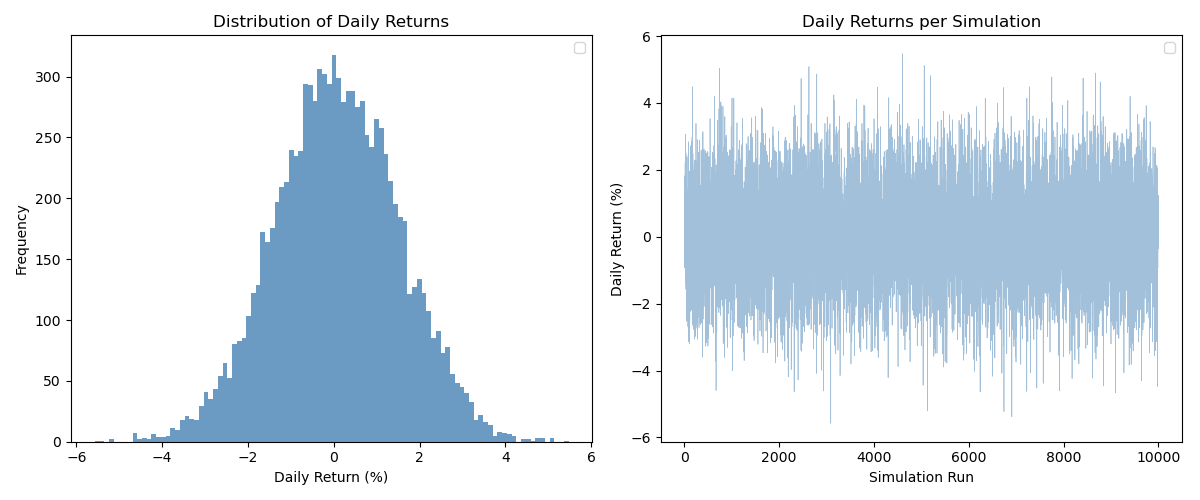

Mean return: 0.08%
Std:         1.45%


In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(daily_return * 100, bins=100, edgecolor='none', color='steelblue', alpha=0.8)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Returns')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(daily_return * 100, alpha=0.5, linewidth=0.5, color='steelblue')
plt.xlabel('Simulation Run')
plt.ylabel('Daily Return (%)')
plt.title('Daily Returns per Simulation')
plt.legend()

plt.tight_layout()
plt.show()


print(f"Mean return: {daily_return.mean()*100:.2f}%")
print(f"Std:         {daily_return.std()*100:.2f}%")

In [26]:
def simulate_paths(N, total_steps, mv_normal_dist, weights, P0=1.0):
    paths = np.zeros((N, total_steps + 1))
    paths[:, 0] = P0
    for n in range(N):
        shocks = mv_normal_dist.rvs(size=total_steps)
        portfolio_steps = shocks @ weights
        paths[n, 1:] = P0 * np.cumprod(1 + portfolio_steps)
    return paths



def simulate_and_animate_slider(N, total_steps, mv_normal_dist, weights, P0=1.0, paths=None):
    if paths is None:
        print("Simulating paths...")
        paths = simulate_paths(N, total_steps, mv_normal_dist, weights, P0)

    time_range = np.arange(0, total_steps + 1)
    all_values = paths.flatten()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, total_steps)
    ax.set_ylim(all_values.min() * 0.99, all_values.max() * 1.01)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Portfolio value")
    ax.axhline(P0, color='black', linewidth=1.5, linestyle='--', label='Starting value')
    ax.legend()

    colors = cm.plasma(np.linspace(0, 1, N))  # her path için farklı renk
    lines = [ax.plot([], [], alpha=0.6, linewidth=1.2, color=colors[i])[0] for i in range(N)]

    def update(frame):
        ax.set_title(f"Minute: {frame} / {total_steps}")
        for i, line in enumerate(lines):
            line.set_data(time_range[:frame + 1], paths[i, :frame + 1])
        fig.canvas.draw()

    slider = widgets.IntSlider(min=0, max=total_steps, step=1, value=0, description="Minute")
    widgets.interact(update, frame=slider)
    plt.show()

### Explanation of simulate paths
path = PORTFOLIO VALUE at a minute

portfolio_steps = for each minute (0-1440), portfolio RETURN as a simple **percentage change**
$$portfolio\_steps = [-0.001, +0.002, -0.0005, ...]$$
i.e. -0.001 means the portfolio lost 0.1% that minute

paths = taking the value at t=0 as P0=1.0 (100%), how the total portfolio VALUE evolves over time
$$paths[n, t] = P_0 \cdot \prod_{i=1}^{t}(1 + portfolio\_steps_i)$$
$$paths = [1.0, 0.999, 1.001, 1.0005, ...]$$

P0=1.0, takes 1.0 to represent %100 and trace percent changes. But nominal portfolio value can also be given to track the possible nominal changes assumed by monte carlo simulation.

Simulating paths...


interactive(children=(IntSlider(value=0, description='Minute', max=1440), Output()), _dom_classes=('widget-int…

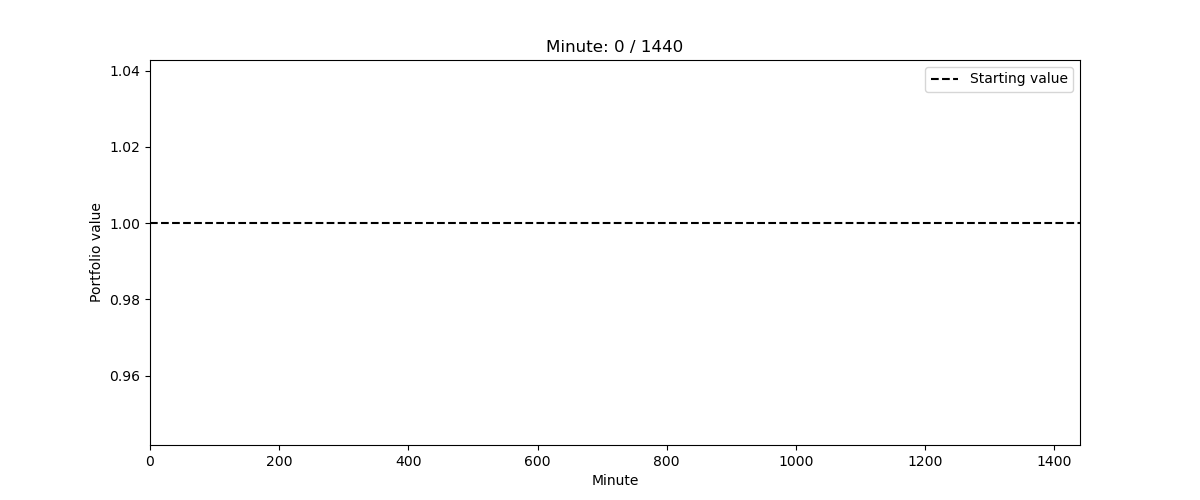

In [27]:
simulate_and_animate_slider(
    N=10,
    total_steps=total_steps,
    mv_normal_dist=mv_normal_dist,
    weights=weights
)